# Import required libraries

In [38]:
import requests
import tarfile
import io
import pandas as pd
import anndata as ad
import scanpy as sc
import celltypist

# If needed, run this in terminal to install the packages:
# pip install requests pandas anndata scanpy celltypist

# Downloading the example dataset

In [39]:
def download_and_extract_data():
    '''
    Downloads the PBMC 3K dataset from 10x Genomics and extracts it to the current directory.

    Read more about this data here: https://www.10xgenomics.com/datasets/3-k-pbm-cs-from-a-healthy-donor-1-standard-1-1-0
    '''
    DATA_URL = "https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz"
    
    response = requests.get(DATA_URL, stream=True)
    response.raise_for_status()
    
    buffer = io.BytesIO()
    for chunk in response.iter_content(chunk_size=8192):
        buffer.write(chunk)
    buffer.seek(0)
    
    with tarfile.open(fileobj=buffer, mode="r:gz") as tar:
        tar.extractall()


download_and_extract_data() # Call the function to download the data

# Load the data into an AnnData object

In [40]:
def load_adata_manually(path):
    '''
    Manually loads the data from the specified path and returns an AnnData object.

    Parameters:
        path (str): The path to the directory containing the matrix.mtx, barcodes.tsv, and genes.tsv files.
    '''

    matrix = scipy.io.mmread(f"{path}/matrix.mtx").T.tocsr()  # cells x genes
    barcodes = pd.read_csv(f"{path}/barcodes.tsv", header=None, names=["barcode"])
    genes = pd.read_csv(f"{path}/genes.tsv", header=None, names=["gene_ids", "gene_symbols"])

    adata = ad.AnnData(
        X=matrix,
        obs=barcodes.set_index("barcode"),
        var=genes.set_index("gene_ids"),
    )

    return adata

In [41]:
DATA_PATH = r"filtered_gene_bc_matrices/hg19"

manual_adata = load_adata_manually(DATA_PATH)
print(manual_adata)

adata = sc.read_10x_mtx(DATA_PATH, cache=False)
print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_symbols'
AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


# Exploring AnnData objects

In [42]:
print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


In [43]:
print(adata.shape)

(2700, 32738)


In [44]:
print(adata.obs)

Empty DataFrame
Columns: []
Index: [AAACATACAACCAC-1, AAACATTGAGCTAC-1, AAACATTGATCAGC-1, AAACCGTGCTTCCG-1, AAACCGTGTATGCG-1, AAACGCACTGGTAC-1, AAACGCTGACCAGT-1, AAACGCTGGTTCTT-1, AAACGCTGTAGCCA-1, AAACGCTGTTTCTG-1, AAACTTGAAAAACG-1, AAACTTGATCCAGA-1, AAAGAGACGAGATA-1, AAAGAGACGCGAGA-1, AAAGAGACGGACTT-1, AAAGAGACGGCATT-1, AAAGATCTGGGCAA-1, AAAGCAGAAGCCAT-1, AAAGCAGATATCGG-1, AAAGCCTGTATGCG-1, AAAGGCCTGTCTAG-1, AAAGTTTGATCACG-1, AAAGTTTGGGGTGA-1, AAAGTTTGTAGAGA-1, AAAGTTTGTAGCGT-1, AAATCAACAATGCC-1, AAATCAACACCAGT-1, AAATCAACCAGGAG-1, AAATCAACCCTATT-1, AAATCAACGGAAGC-1, AAATCAACTCGCAA-1, AAATCATGACCACA-1, AAATCCCTCCACAA-1, AAATCCCTGCTATG-1, AAATGTTGAACGAA-1, AAATGTTGCCACAA-1, AAATGTTGTGGCAT-1, AAATTCGAAGGTTC-1, AAATTCGAATCACG-1, AAATTCGAGCTGAT-1, AAATTCGAGGAGTG-1, AAATTCGATTCTCA-1, AAATTGACACGACT-1, AAATTGACTCGCTC-1, AACAAACTCATTTC-1, AACAAACTTTCGTT-1, AACAATACGACGAG-1, AACACGTGCAGAGG-1, AACACGTGGAAAGT-1, AACACGTGGAACCT-1, AACACGTGGCTACA-1, AACACGTGTACGAC-1, AACAGCACAAGAGT-1, AACATTGATG

In [45]:
adata.var

,gene_ids
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945
...,...
AC145205.1,ENSG00000215635
BAGE5,ENSG00000268590
CU459201.1,ENSG00000251180
AC002321.2,ENSG00000215616


In [46]:
# AnnData stores the gene count matrix as a sparse matrix, which is more memory efficient than a large dense matrix.
adata.X

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 2286884 stored elements and shape (2700, 32738)>

In [47]:
adata.to_df()

,MIR1302-10,FAM138A,OR4F5,RP11-34P13.7,RP11-34P13.8,AL627309.1,RP11-34P13.14,RP11-34P13.9,AP006222.2,RP4-669L17.10,...,KIR3DL2-1,AL590523.1,CT476828.1,PNRC2-1,SRSF10-1,AC145205.1,BAGE5,CU459201.1,AC002321.2,AC002321.1
AAACATACAACCAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGAGCTAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGATCAGC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGCTTCCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGTATGCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTCTACTGAGGCA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTCTACTTCCTCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGCATGAGAGGC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Exploring some Scanpy functions for quality control

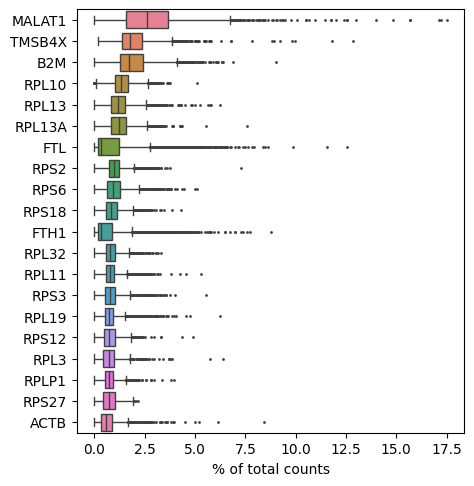

In [48]:
# Plot the 20 genes with the highest read counts

sc.pl.highest_expr_genes(adata, n_top=20)

In [49]:
QC_adata = adata.copy()

sc.pp.calculate_qc_metrics(QC_adata, percent_top=None, log1p=False, inplace=True)

In [50]:
print(adata)
print(QC_adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
AnnData object with n_obs × n_vars = 2700 × 32738
    obs: 'n_genes_by_counts', 'total_counts'
    var: 'gene_ids', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'


In [51]:
# n_genes_by_counts: The number of genes that have at least one read count in each cell.
# total_counts: The total number of reads for each cell.

QC_adata.obs

,n_genes_by_counts,total_counts
AAACATACAACCAC-1,781,2421.0
AAACATTGAGCTAC-1,1352,4903.0
AAACATTGATCAGC-1,1131,3149.0
AAACCGTGCTTCCG-1,960,2639.0
AAACCGTGTATGCG-1,522,981.0
...,...,...
TTTCGAACTCTCAT-1,1155,3461.0
TTTCTACTGAGGCA-1,1227,3447.0
TTTCTACTTCCTCG-1,622,1684.0
TTTGCATGAGAGGC-1,454,1024.0


In [52]:
QC_adata.var

,gene_ids,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
MIR1302-10,ENSG00000243485,0,0.0,100.0,0.0
FAM138A,ENSG00000237613,0,0.0,100.0,0.0
OR4F5,ENSG00000186092,0,0.0,100.0,0.0
RP11-34P13.7,ENSG00000238009,0,0.0,100.0,0.0
RP11-34P13.8,ENSG00000239945,0,0.0,100.0,0.0
...,...,...,...,...,...
AC145205.1,ENSG00000215635,0,0.0,100.0,0.0
BAGE5,ENSG00000268590,0,0.0,100.0,0.0
CU459201.1,ENSG00000251180,0,0.0,100.0,0.0
AC002321.2,ENSG00000215616,0,0.0,100.0,0.0


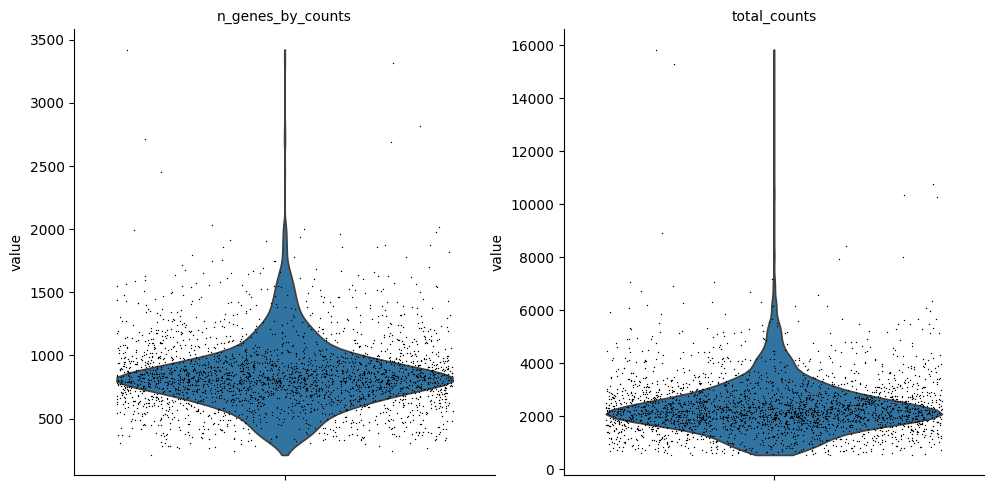

In [53]:
sc.pl.violin(QC_adata, ['n_genes_by_counts', 'total_counts'], jitter=0.4, multi_panel=True)

# Filtering out doublets and dying cells

In [54]:
QC_adata.var['MT_gene'] = QC_adata.var_names.str.startswith('MT-')
QC_adata.var

,gene_ids,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,MT_gene
MIR1302-10,ENSG00000243485,0,0.0,100.0,0.0,False
FAM138A,ENSG00000237613,0,0.0,100.0,0.0,False
OR4F5,ENSG00000186092,0,0.0,100.0,0.0,False
RP11-34P13.7,ENSG00000238009,0,0.0,100.0,0.0,False
RP11-34P13.8,ENSG00000239945,0,0.0,100.0,0.0,False
...,...,...,...,...,...,...
AC145205.1,ENSG00000215635,0,0.0,100.0,0.0,False
BAGE5,ENSG00000268590,0,0.0,100.0,0.0,False
CU459201.1,ENSG00000251180,0,0.0,100.0,0.0,False
AC002321.2,ENSG00000215616,0,0.0,100.0,0.0,False


In [55]:
QC_adata.var[QC_adata.var['MT_gene'] == True]

,gene_ids,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,MT_gene
MT-ND1,ENSG00000198888,2558,4.818889,5.259259,13011.0,True
MT-ND2,ENSG00000198763,2416,4.030370,10.518519,10882.0,True
MT-CO1,ENSG00000198804,2686,14.515185,0.518519,39191.0,True
MT-CO2,ENSG00000198712,2460,7.068148,8.888889,19084.0,True
MT-ATP8,ENSG00000228253,32,0.012963,98.814815,35.0,True
MT-ATP6,ENSG00000198899,2014,2.337407,25.407407,6311.0,True
MT-CO3,ENSG00000198938,2647,7.144444,1.962963,19290.0,True
MT-ND3,ENSG00000198840,557,0.253704,79.370370,685.0,True
MT-ND4L,ENSG00000212907,398,0.165185,85.259259,446.0,True
MT-ND4,ENSG00000198886,2588,5.096296,4.148148,13760.0,True


In [56]:
sc.pp.calculate_qc_metrics(QC_adata, qc_vars=['MT_gene'], percent_top=None, log1p=False, inplace=True)
QC_adata

AnnData object with n_obs × n_vars = 2700 × 32738
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_MT_gene', 'pct_counts_MT_gene'
    var: 'gene_ids', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'MT_gene'

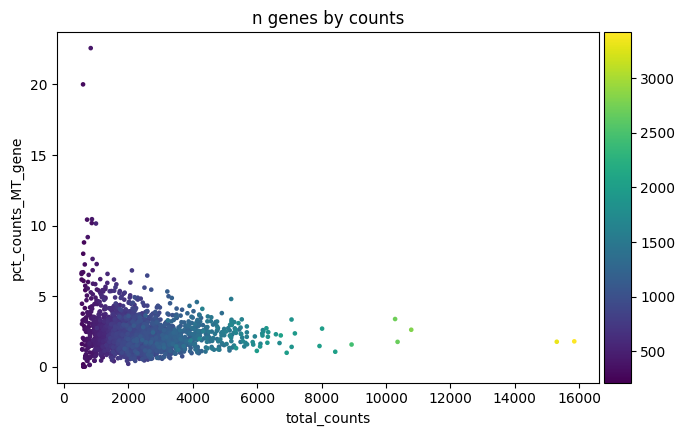

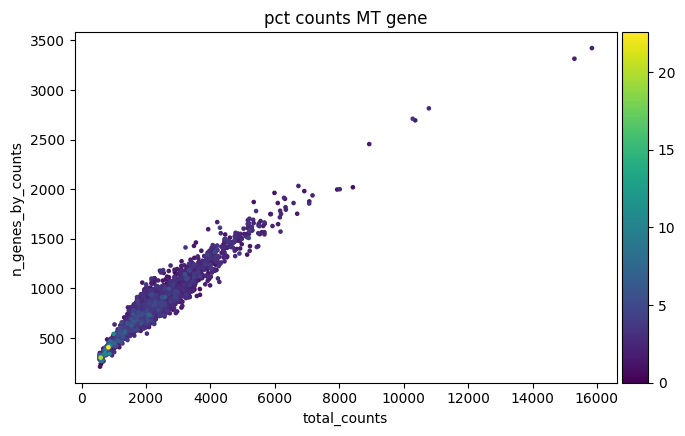

In [57]:
sc.pl.scatter(QC_adata, x='total_counts', y='pct_counts_MT_gene', color='n_genes_by_counts')
sc.pl.scatter(QC_adata, x='total_counts', y='n_genes_by_counts', color='pct_counts_MT_gene')

Notice some cells have a high proportion of mitochondrial genes (dying cells), while others have suspiciously high total counts (doublets).


We will filter out cells with > 5% mitochondrial gene counts, as well as cells with > 2500 total counts.

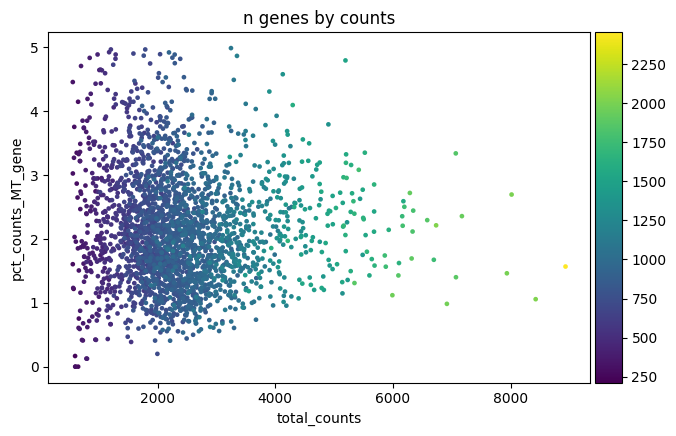

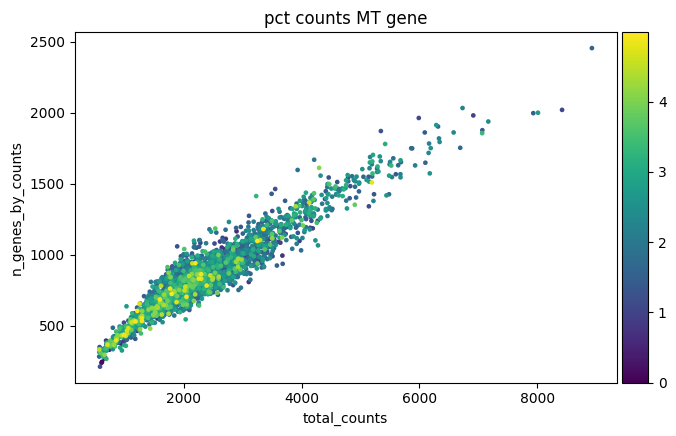

In [58]:
filtered_QC_adata = QC_adata.copy()

filtered_QC_adata = filtered_QC_adata[filtered_QC_adata.obs.pct_counts_MT_gene < 5, :] # Dying cell filter
filtered_QC_adata = filtered_QC_adata[filtered_QC_adata.obs.n_genes_by_counts < 2500, :] # Doublet filter

sc.pl.scatter(filtered_QC_adata, x='total_counts', y='pct_counts_MT_gene', color='n_genes_by_counts')
sc.pl.scatter(filtered_QC_adata, x='total_counts', y='n_genes_by_counts', color='pct_counts_MT_gene')

In [59]:
print(adata.shape)

print(filtered_QC_adata.shape)

(2700, 32738)
(2638, 32738)


# Normalize and log transform

Normalisation is done to adjust the sampling effects or technical biases in the data.

Capture efficiency (efficiency with which a particular assay or method to detect the RNA in cell), sequencing depth (amount of RNA that is sequenced in an experiment), and other technical confounders (such as quality of the samples or the performance of the instrument) can all introduce bias and variation in gene expression data.

In [60]:
norm_adata = filtered_QC_adata.copy()

sc.pp.normalize_total(norm_adata, target_sum=1e4) # Normalize the sum of all counts in each cell to 10,000
sc.pp.log1p(norm_adata) # Log-transform the data (log(x + 1) is used to avoid taking the log of zero, which is undefined)

# Filter for highly variable genes

In [61]:
hvg_filtered_norm_adata = norm_adata.copy()

sc.pp.highly_variable_genes(hvg_filtered_norm_adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

hvg_filtered_norm_adata.var

,gene_ids,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,MT_gene,highly_variable,means,dispersions,dispersions_norm
MIR1302-10,ENSG00000243485,0,0.0,100.0,0.0,False,False,1.000000e-12,NaN,NaN
FAM138A,ENSG00000237613,0,0.0,100.0,0.0,False,False,1.000000e-12,NaN,NaN
OR4F5,ENSG00000186092,0,0.0,100.0,0.0,False,False,1.000000e-12,NaN,NaN
RP11-34P13.7,ENSG00000238009,0,0.0,100.0,0.0,False,False,1.000000e-12,NaN,NaN
RP11-34P13.8,ENSG00000239945,0,0.0,100.0,0.0,False,False,1.000000e-12,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
AC145205.1,ENSG00000215635,0,0.0,100.0,0.0,False,False,1.000000e-12,NaN,NaN
BAGE5,ENSG00000268590,0,0.0,100.0,0.0,False,False,1.000000e-12,NaN,NaN
CU459201.1,ENSG00000251180,0,0.0,100.0,0.0,False,False,1.000000e-12,NaN,NaN
AC002321.2,ENSG00000215616,0,0.0,100.0,0.0,False,False,1.000000e-12,NaN,NaN


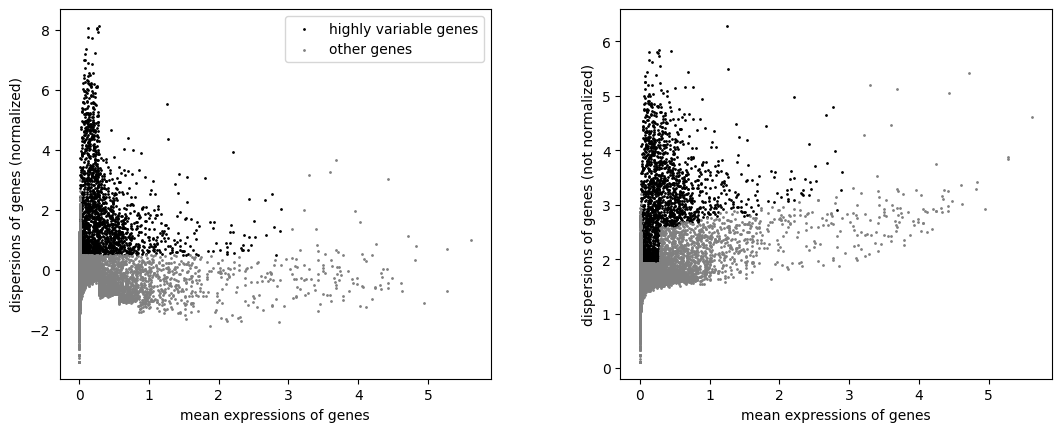

In [62]:
sc.pl.highly_variable_genes(hvg_filtered_norm_adata)

In [63]:
hvg_filtered_norm_adata.raw = hvg_filtered_norm_adata.copy() # Store the non-filtered genes for cell labeling later
hvg_filtered_norm_adata = hvg_filtered_norm_adata[:, hvg_filtered_norm_adata.var.highly_variable]

print(adata.shape)
print(hvg_filtered_norm_adata.shape)

(2700, 32738)
(2638, 2013)


# Dimension reduction with PCA


Note that there are many ways to reduce dimensions. PCA is relatively quick and easy. A more complicated example is scVI (variational auto-encoder).

In [64]:

pca_adata = hvg_filtered_norm_adata.copy()

sc.pp.scale(pca_adata) # scale to unit variance for PCA
sc.tl.pca(pca_adata, svd_solver='arpack')

pca_adata


AnnData object with n_obs × n_vars = 2638 × 2013
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_MT_gene', 'pct_counts_MT_gene'
    var: 'gene_ids', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'MT_gene', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

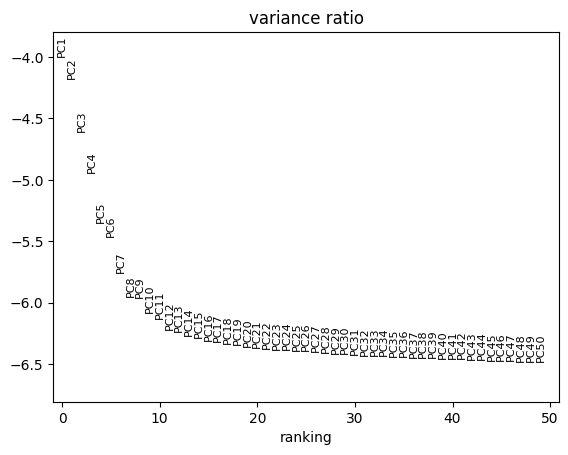

In [65]:
sc.pl.pca_variance_ratio(pca_adata, n_pcs=50, log=True)

In [66]:
pd.DataFrame(
    pca_adata.obsm["X_pca"][:, :15],
    index=pca_adata.obs_names,
    columns=[f"PC{i}" for i in range(1, 16)]
)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
AAACATACAACCAC-1,-4.264654,0.835830,0.566175,-2.317441,1.069607,-0.672914,0.124324,-0.405479,0.385172,0.461325,0.864170,1.310772,-1.293728,0.091366,-1.127664
AAACATTGAGCTAC-1,-0.449674,-0.559251,-5.955885,9.118000,1.172408,-2.597029,1.205275,1.673800,-2.564466,-0.194315,0.601859,2.555875,0.121256,2.951120,1.059374
AAACATTGATCAGC-1,-1.800017,0.287669,2.704581,-2.062096,0.407572,-4.043532,0.923424,-0.434654,-0.907745,-0.491199,0.505594,-0.048116,-0.703293,0.148716,-2.235464
AAACCGTGCTTCCG-1,9.957274,-3.033416,0.732101,0.498465,0.960977,-0.240455,1.286591,-1.287226,1.738130,-1.353050,0.271553,0.175129,-0.248963,0.322410,0.468558
AAACCGTGTATGCG-1,-2.688714,-0.076486,6.696296,4.115441,-1.476673,6.830926,-0.923640,0.017146,1.180875,1.228292,-3.893399,-0.275413,-0.269230,-2.468971,0.146912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,11.349672,-3.628158,0.117414,0.343269,0.169509,-2.097756,-0.943362,3.266176,-5.751930,1.107600,0.926195,3.976187,1.056723,-0.383005,-1.516292
TTTCTACTGAGGCA-1,-1.699120,1.520957,-3.680129,5.960255,-0.150578,-4.772326,0.692121,1.344176,-0.795269,3.231067,0.229930,0.657048,0.044134,-1.115155,0.966778
TTTCTACTTCCTCG-1,-2.684998,-0.243851,-7.504775,3.809015,-0.417318,0.692768,0.026535,-0.368430,1.353099,0.140285,-0.361173,0.758058,0.506810,-0.664016,1.251436
TTTGCATGAGAGGC-1,-3.240360,0.467806,-6.870568,7.069377,-1.332798,2.183355,-0.531429,-1.870922,0.420248,1.326154,1.242903,-1.252432,-2.639732,-0.847903,-2.620652


# K-nearest Neighbors and UMAP

In [67]:
sc.pp.neighbors(pca_adata, n_pcs=15) # Run KNN graph construction using the first 15 principal components
sc.tl.umap(pca_adata, random_state=42) # Run UMAP dimensionality reduction on the KNN graph

pca_adata

AnnData object with n_obs × n_vars = 2638 × 2013
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_MT_gene', 'pct_counts_MT_gene'
    var: 'gene_ids', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'MT_gene', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [68]:
pca_adata.obsm["X_umap"]

array([[-5.3628187, 10.44069  ],
       [16.276808 ,  7.8190627],
       [-6.8360453,  8.235128 ],
       ...,
       [14.751614 ,  9.578304 ],
       [13.4569235,  8.086506 ],
       [-3.1639242, 10.058806 ]], dtype=float32)

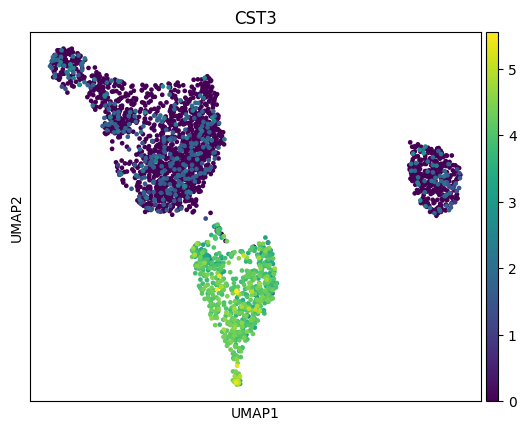

In [69]:
sc.pl.umap(pca_adata, color='CST3')

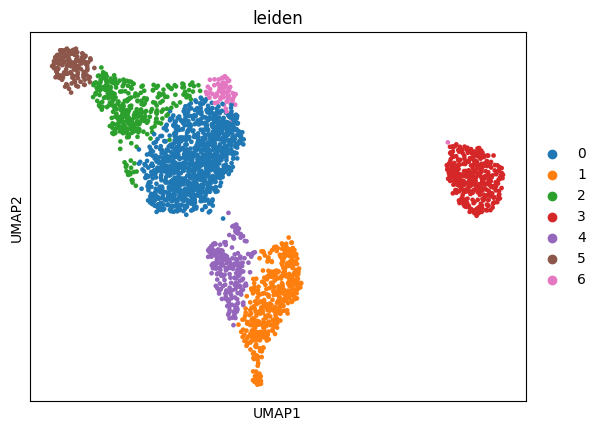

In [70]:
sc.tl.leiden(pca_adata, resolution=0.5, random_state=42) # Clusters based on the KNN graph using the Leiden algorithm
sc.pl.umap(pca_adata, color="leiden")

# Cell labeling (finally!)

### Option 1: Look at biomarkers

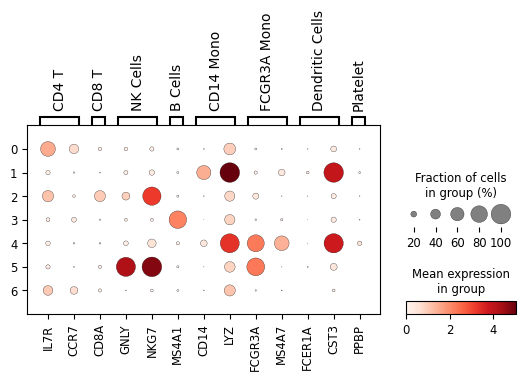

In [71]:
marker_genes = {
    "CD4 T": ["IL7R", "CCR7"],
    "CD8 T": ["CD8A"],
    "NK Cells": ["GNLY", "NKG7"],
    "B Cells": ["MS4A1"],
    "CD14 Mono": ["CD14", "LYZ"],
    "FCGR3A Mono": ["FCGR3A", "MS4A7"],
    "Dendritic Cells": ["FCER1A", "CST3"],
    "Platelet": ["PPBP"],
}

sc.pl.dotplot(pca_adata, marker_genes, groupby="leiden", use_raw=True) # Using the HVG filtered genes won't work here, because some are filtered out

... storing 'cluster_label_cell_type' as categorical


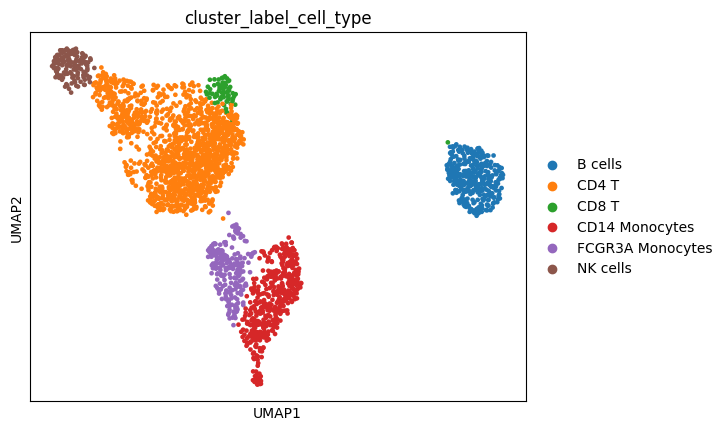

In [76]:
# Note: Don't trust these labels, just for demonstration purposes
label_map = {
    "0": "CD4 T",
    "1": "CD14 Monocytes",
    "2": "CD4 T",
    "3": "B cells",
    "4": "FCGR3A Monocytes",
    "5": "NK cells",
    "6": "CD8 T"
}

pca_adata.obs["cluster_label_cell_type"] = pca_adata.obs["leiden"].map(label_map)
sc.pl.umap(pca_adata, color="cluster_label_cell_type")

# Option 2: Label each cell individually

In [73]:
# Learn more about celltypist here: https://www.celltypist.org/

celltypist.models.download_models(model=["Adult_COVID19_PBMC.pkl", "Immune_All_High.pkl"])

📂 Storing models in C:\Users\jpdyc\.celltypist\data\models
💾 Total models to download: 2
⏩ Skipping [1/2]: Immune_All_High.pkl (file exists)
⏩ Skipping [2/2]: Adult_COVID19_PBMC.pkl (file exists)


In [74]:
celltypist_predictions = celltypist.annotate(pca_adata, model="Immune_All_High.pkl", majority_voting=True)
#celltypist_predictions = celltypist.annotate(pca_adata, model="Adult_COVID19_PBMC.pkl", majority_voting=True)
print("")
print(celltypist_predictions)

👀 Invalid expression matrix in `.X`, expect log1p normalized expression to 10000 counts per cell; will use `.raw.X` instead
🔬 Input data has 2638 cells and 32738 genes
🔗 Matching reference genes in the model
🧬 5278 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!



CellTypist prediction result for 2638 query cells
    predicted_labels: data frame with 3 columns ('predicted_labels', 'over_clustering', 'majority_voting')
    decision_matrix: data frame with 2638 query cells and 32 cell types
    probability_matrix: data frame with 2638 query cells and 32 cell types
    adata: AnnData object referred


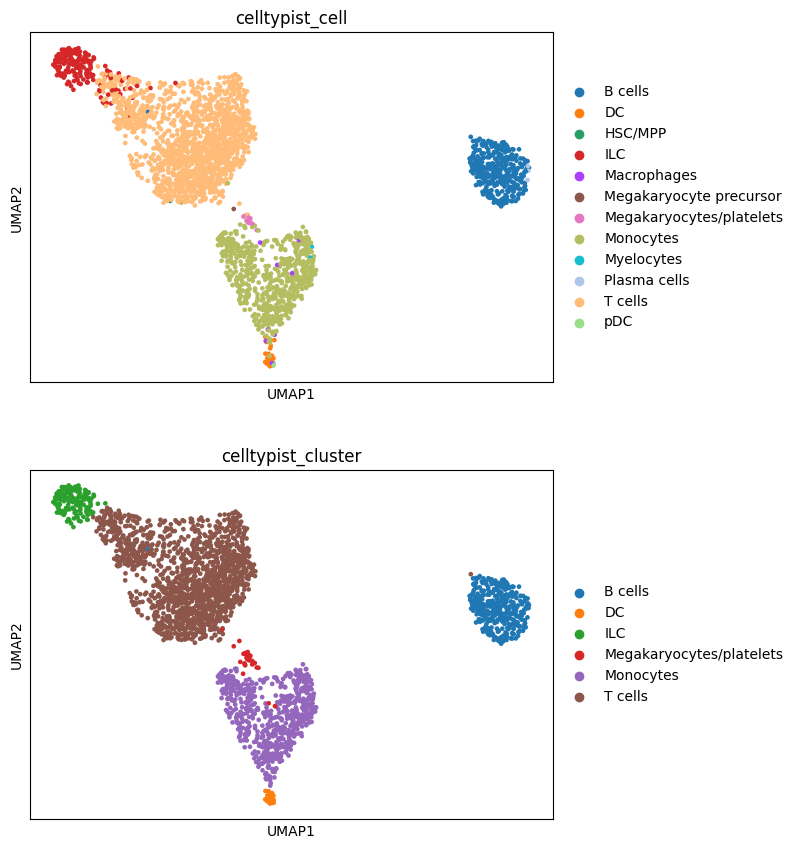

In [75]:
pca_adata.obs["celltypist_cell"] = celltypist_predictions.predicted_labels["predicted_labels"]
pca_adata.obs["celltypist_cluster"] = celltypist_predictions.predicted_labels["majority_voting"]

# Plot side by side
sc.pl.umap(pca_adata, color=["celltypist_cell", "celltypist_cluster"], ncols=1)